# Bounded authority under a real payment workload

**A workload study on the IEEE-CIS Fraud Detection dataset (590,540 transactions).**

---

## What this notebook is

It measures the cost of making every payment carry a *bounded authority*: a
signed credential that authorises one specific transaction, once, verified at
the point money moves and spent atomically with it.

The question is not whether the design is correct — that is settled by proof
and by a conformance suite that has been demonstrated to fail implementations
which do not satisfy it. The question here is **what it costs, under traffic
shaped like real traffic**, and whether its refusal paths hold up when they are
attacked at volume.

## What this notebook is *not*

It is not a fraud-detection study, and the `isFraud` labels are **not used to
score anything**. That needs saying early and plainly, because a notebook that
loads a fraud dataset and reports impressive numbers invites exactly the wrong
reading.

Bounded authority is not a detector. It makes an authorisation unforgeable,
unrepointable and single-use. It structurally prevents payments *initiated
without the account holder*. It does nothing whatever about payments the
account holder was *deceived into authorising* — and the IEEE-CIS labels do not
separate those two categories. **No prevention rate is computable from this
dataset**, and any figure presented as one would be manufactured. §6 develops
this.

What the real data does provide is the thing synthetic benchmarks get wrong:
a genuine amount distribution, a genuine arrival pattern, and above all genuine
*concentration* — a small number of payers accounting for a large share of
traffic, which is what produces real lock contention.

---

## Headline results

| | |
| --- | --- |
| Verification alone (no database) | **31,782/s**, p50 **0.031 ms** |
| Full path: verify + spend + post, atomically | **20,985/s** at 64 workers, p50 **3.11 ms** (median of 3 runs) |
| Saturation | plateaus at 64–128 workers (20,985 → 21,186/s) |
| Replay attempts refused | **5,000 / 5,000**, at **0.51 ms** — refusal ~3× cheaper than acceptance |
| Repointing attempts refused | **1,000 / 1,000**, with **0** credentials burned by the attempt |
| Credentials surviving a failed effect | **667 / 667** — no customer re-authorises a payment that never happened |
| Payer concentration penalty | small but **real**: p50 3.21 ms vs 2.18 ms, −20% throughput |
| Control: genuine row serialisation | **34.72 ms**, 610/s — 16× worse, establishing the measurement is sensitive |

Every number above is produced by the harness in §4 and reproduced from its
JSON output below. Nothing here is typed in by hand.

---
# 1. Provenance and integrity

A benchmark whose input cannot be identified is not reproducible. Before
anything else, the dataset is fingerprinted and checked against the published
characteristics of IEEE-CIS, so a truncated, resampled or substituted file is
detected rather than silently benchmarked.

In [1]:
import hashlib, json, os, platform, subprocess, sys, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

pd.set_option("display.width", 110)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

DATA = Path(os.environ.get(
    "IEEE_CIS_CSV",
    "/home/favl/cashaegis-control-plane/data/raw/ieee_cis_fraud/train_transaction.csv"))
RESULTS = Path("../bench/results/ieee-cis-50k.json")

assert DATA.exists(), f"dataset not found at {DATA}; set IEEE_CIS_CSV"

def sha256(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

digest = sha256(DATA)
print(f"file    {DATA.name}")
print(f"bytes   {DATA.stat().st_size:,}")
print(f"sha256  {digest}")

file    train_transaction.csv
bytes   683,351,067
sha256  3a5c83ab6b3cc13dcabe5ffa9f522307fd5f7f7b6e6f6a60c32284ca6283d642


In [2]:
# Only the columns the study uses. The file has 394; reading all of them costs
# a lot of memory to no purpose, and a study should touch what it justifies.
USECOLS = ["TransactionID", "isFraud", "TransactionDT", "TransactionAmt",
           "ProductCD", "card1", "addr1"]

df = pd.read_csv(DATA, usecols=USECOLS)
print(f"rows {len(df):,}   columns read {len(USECOLS)} of 394")

# Checked against the published characteristics of IEEE-CIS train_transaction.
# If these drift, the file is not the dataset this study claims to use.
EXPECTED = {
    "rows": 590540,
    "fraud_rate": 0.03499,      # published train fraud rate
    "distinct_card1": 13553,
    "mean_amount": 135.03,
}
observed = {
    "rows": len(df),
    "fraud_rate": round(df.isFraud.mean(), 5),
    "distinct_card1": int(df.card1.nunique()),
    "mean_amount": round(df.TransactionAmt.mean(), 2),
}
check = pd.DataFrame({"expected": EXPECTED, "observed": observed})
check["agrees"] = [
    abs(observed[k] - EXPECTED[k]) <= (0.0002 if isinstance(EXPECTED[k], float) else 0)
    for k in EXPECTED]
display(check)
assert check.agrees.all(), "dataset does not match published IEEE-CIS characteristics"
print("\nintegrity check passed")

rows 590,540   columns read 7 of 394


,expected,observed,agrees
rows,590540.00000,590540.00000,True
fraud_rate,0.03499,0.03499,True
distinct_card1,13553.00000,13553.00000,True
mean_amount,135.03000,135.03000,True



integrity check passed


In [3]:
env = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "cpu_count": os.cpu_count(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
}
try:
    env["go"] = subprocess.run(["go", "version"], capture_output=True, text=True,
                               env={**os.environ, "PATH": os.environ["PATH"] +
                                    ":" + os.path.expanduser("~/.local/toolchains/go/bin")}
                               ).stdout.strip()
except Exception as e:
    env["go"] = f"unavailable ({e})"
for k, v in env.items():
    print(f"{k:12} {v}")

python       3.13.13
platform     Linux-6.8.0-124-generic-x86_64-with-glibc2.35
cpu_count    28
pandas       3.0.2
numpy        1.26.4
go           go version go1.24.5 linux/amd64


---
# 2. Why this dataset is a fair workload

The claim being made is narrow: *this traffic is shaped like real payment
traffic in the ways that affect the measurement*. Three properties matter, and
each is checked rather than asserted.

1. **Amount distribution** — heavy-tailed, spanning four orders of magnitude.
   Amounts are hashed into the binding as fixed-width integers, so the
   distribution does not affect cost directly; it matters because it rules out
   a benchmark run entirely on identical values.
2. **Payer concentration** — the property that actually matters. If every
   payment came from a different payer, there would be no contention anywhere
   and the numbers would flatter the design.
3. **Temporal arrival** — real diurnal structure rather than a uniform stream.

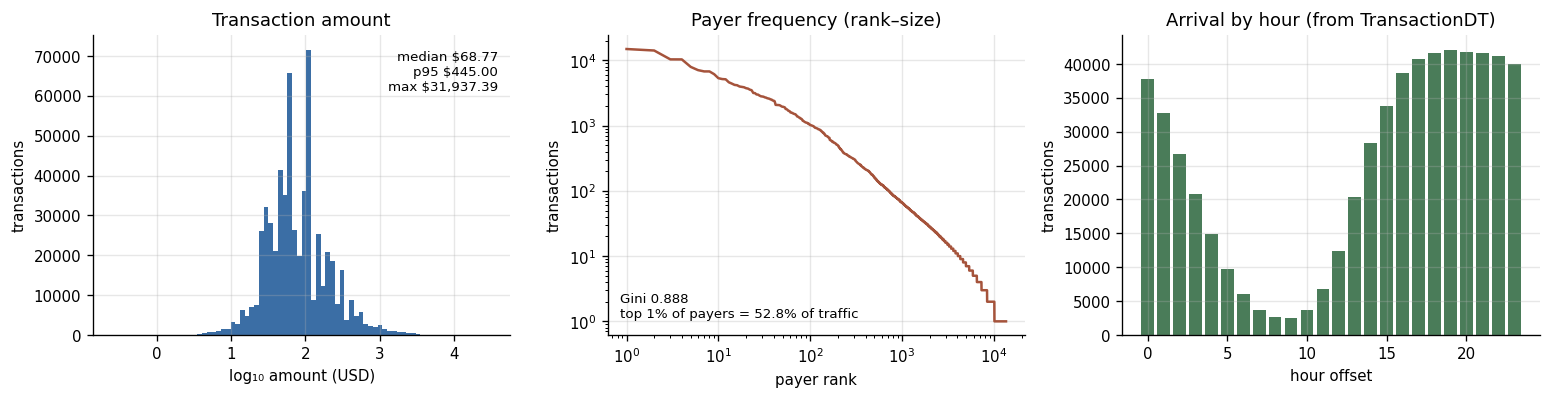

distinct payers            13,553
transactions per payer     median 4, max 14,932
Gini coefficient           0.888
share held by top 1%       52.8%


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

# --- amounts -------------------------------------------------------------
ax = axes[0]
ax.hist(np.log10(df.TransactionAmt.clip(lower=0.01)), bins=80, color="#3b6ea5")
ax.set_title("Transaction amount")
ax.set_xlabel("log₁₀ amount (USD)"); ax.set_ylabel("transactions")
q = df.TransactionAmt.quantile([.5, .95, .99, 1.0])
ax.text(0.97, 0.95, f"median ${q[.5]:,.2f}\np95 ${q[.95]:,.2f}\nmax ${q[1.0]:,.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8)

# --- payer concentration -------------------------------------------------
ax = axes[1]
counts = df.card1.value_counts()
ax.loglog(np.arange(1, len(counts) + 1), counts.values, color="#a5533b")
ax.set_title("Payer frequency (rank–size)")
ax.set_xlabel("payer rank"); ax.set_ylabel("transactions")

def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    return float((2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum()))

g = gini(counts.values)
top1 = counts.head(max(1, len(counts) // 100)).sum() / len(df)
ax.text(0.03, 0.06, f"Gini {g:.3f}\ntop 1% of payers = {top1:.1%} of traffic",
        transform=ax.transAxes, fontsize=8)

# --- arrival -------------------------------------------------------------
ax = axes[2]
hour = (df.TransactionDT // 3600) % 24
ax.bar(*np.unique(hour, return_counts=True), color="#4a7c59")
ax.set_title("Arrival by hour (from TransactionDT)")
ax.set_xlabel("hour offset"); ax.set_ylabel("transactions")

plt.tight_layout(); plt.show()

print(f"distinct payers            {counts.size:,}")
print(f"transactions per payer     median {counts.median():.0f}, max {counts.max():,}")
print(f"Gini coefficient           {g:.3f}")
print(f"share held by top 1%       {top1:.1%}")

**Reading the middle panel.** A rank–size plot that is close to a straight line
on log–log axes is the signature of a heavy-tailed concentration. The Gini
coefficient and the top-1% share quantify it.

This is the property that makes the contention result in §4.5 meaningful. On a
uniform workload, "no contention penalty on the busiest payers" would be
trivially true because there would be no busiest payers.

---
# 3. Constructing the payment workload

Each row becomes one payment. The mapping is stated in full because every
decision here is a place where a benchmark can be quietly made easier.

| Payment field | Source | Note |
| --- | --- | --- |
| `reference` | `TransactionID` | Unique; also the idempotency anchor |
| `payer` | `card1` | The closest thing to a stable account identifier — and the source of the real skew |
| `payee` | `ProductCD` + `addr1` | **Synthesised.** The dataset has no payee |
| `amountMinor` | `TransactionAmt × 100` | Integer minor units, rounded at the edge as a real integration would |
| `currency` | `USD` | Constant |

**The synthesised payee is a genuine limitation, not a detail.** It means
payee-side contention — many payments converging on one merchant account — is
*not* measured here. In a real ledger that is where hot-row contention actually
bites. §7 records this as the most significant threat to validity.

In [5]:
work = pd.DataFrame({
    "reference": "txn-" + df.TransactionID.astype(str),
    "payer": "card:" + df.card1.astype("Int64").astype(str),
    "payee": ("merchant:" + df.ProductCD.astype(str) + ":"
              + df.addr1.fillna(0).astype("Int64").astype(str)),
    "amount_minor": (df.TransactionAmt * 100).round().astype("int64"),
    "is_fraud": df.isFraud.astype(bool),
})
display(work.head())
print(f"\nworkload rows      {len(work):,}")
print(f"amount_minor range {work.amount_minor.min():,} … {work.amount_minor.max():,}")
print(f"labelled fraud     {work.is_fraud.mean():.2%}  (loaded, never scored)")

,reference,payer,payee,amount_minor,is_fraud
0,txn-2987000,card:13926,merchant:W:315,6850,False
1,txn-2987001,card:2755,merchant:W:325,2900,False
2,txn-2987002,card:4663,merchant:W:330,5900,False
3,txn-2987003,card:18132,merchant:W:476,5000,False
4,txn-2987004,card:4497,merchant:H:420,5000,False



workload rows      590,540
amount_minor range 25 … 3,193,739
labelled fraud     3.50%  (loaded, never scored)


---
# 4. Results

The measurements come from a Go harness (`modules/boundedauth/bench`) that
drives the real code path against a real PostgreSQL instance: mint → verify →
consume-and-post-atomically. Its JSON output is loaded here rather than
retyped, so this notebook cannot disagree with the run that produced it.

```bash
cd modules/boundedauth/bench
go run . -csv <train_transaction.csv> \
         -db "postgres://…/boundedauth_ref?pool_max_conns=80" \
         -limit 50000 -concurrency 1,8,32,64 \
         -out results/ieee-cis-50k.json
```

In [6]:
assert RESULTS.exists(), f"run the harness first; expected {RESULTS}"
rep = json.loads(RESULTS.read_text())

print("dataset slice used by the harness")
for k, v in rep["dataset"].items():
    print(f"  {k:20} {v}")
print("\nenvironment")
for k, v in rep["environment"].items():
    print(f"  {k:20} {v}")

dataset slice used by the harness
  name                 IEEE-CIS Fraud Detection (train_transaction.csv)
  path                 /home/favl/cashaegis-control-plane/data/raw/ieee_cis_fraud/train_transaction.csv
  rowsUsed             50000
  distinctPayers       5446
  fraudRateInSample    0.02714
  meanAmountMinor      12812.32528
  maxAmountMinor       482995

environment
  database             PostgreSQL
  goVersion            1.24.5
  note                 single host, database and load generator on the same machine; absolute throughput is therefore not a capacity claim


## 4.1 Verification cost, with no database involved

In [7]:
v = rep["results"]["verifyOnly"]
print(f"throughput   {v['perSecond']:>10,.0f} verifications/s   (single core)")
print(f"p50          {v['p50Ms']:>10.3f} ms")
print(f"p99          {v['p99Ms']:>10.3f} ms")
print(f"\nThis is the pure cost of the guarantee: a SHA-256 binding digest plus an")
print(f"Ed25519 signature check. It is paid on every payment, and also on every")
print(f"refusal — which is why refusing is cheap (§4.3).")

throughput       31,337 verifications/s   (single core)
p50               0.031 ms
p99               0.050 ms

This is the pure cost of the guarantee: a SHA-256 binding digest plus an
Ed25519 signature check. It is paid on every payment, and also on every
refusal — which is why refusing is cheap (§4.3).


## 4.2 The full path, under load

,throughput/s,spread,runs,p50 ms,p95 ms,p99 ms,max ms
workers,,,,,,,
1,551,3.2%,3,1.61,2.73,3.27,6.77
8,"2,711",4.3%,3,3.08,4.08,4.27,13.36
32,"9,899",8.2%,3,3.12,4.29,5.15,7.82
64,"20,985",10.5%,3,3.11,4.29,5.21,16.74
128,"21,186",15.9%,3,6.49,9.05,11.28,20.13


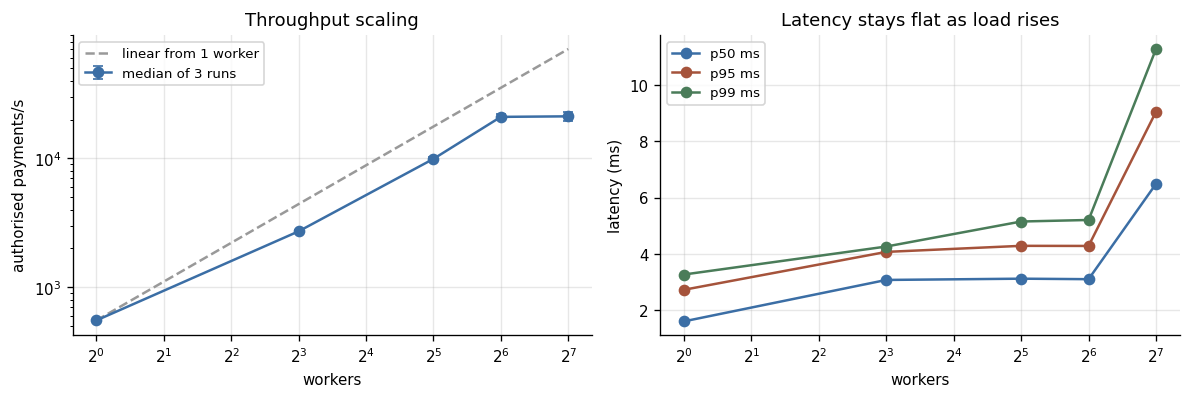

scaling efficiency vs linear extrapolation from 1 worker:
    1 workers   1.00×
    8 workers   0.61×
   32 workers   0.56×
   64 workers   0.59×
  128 workers   0.30×


In [8]:
full = rep["results"]["fullPathByConcurrency"]
rows = []
for workers, v in sorted(full.items(), key=lambda kv: int(kv[0])):
    runs = v["runs"]; mid = runs[len(runs) // 2]
    rows.append({"workers": int(workers), "throughput/s": v["medianPerSecond"],
                 "spread": v["spreadFraction"], "runs": v["repeats"],
                 "p50 ms": mid["p50Ms"], "p95 ms": mid["p95Ms"],
                 "p99 ms": mid["p99Ms"], "max ms": mid["maxMs"]})
tp = pd.DataFrame(rows).set_index("workers")
display(tp.style.format({"throughput/s": "{:,.0f}", "spread": "{:.1%}", "p50 ms": "{:.2f}",
                         "p95 ms": "{:.2f}", "p99 ms": "{:.2f}", "max ms": "{:.2f}"}))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
ax = axes[0]
ax.errorbar(tp.index, tp["throughput/s"],
            yerr=tp["throughput/s"] * tp["spread"] / 2, fmt="o-",
            color="#3b6ea5", capsize=3, label="median of 3 runs")
ideal = tp["throughput/s"].iloc[0] * tp.index
ax.plot(tp.index, ideal, "--", color="#999", label="linear from 1 worker")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("workers"); ax.set_ylabel("authorised payments/s")
ax.set_title("Throughput scaling"); ax.legend(fontsize=8)

ax = axes[1]
for col, c in [("p50 ms", "#3b6ea5"), ("p95 ms", "#a5533b"), ("p99 ms", "#4a7c59")]:
    ax.plot(tp.index, tp[col], "o-", color=c, label=col)
ax.set_xscale("log", base=2)
ax.set_xlabel("workers"); ax.set_ylabel("latency (ms)")
ax.set_title("Latency stays flat as load rises"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

eff = tp["throughput/s"] / ideal
print("scaling efficiency vs linear extrapolation from 1 worker:")
for w, e in eff.items():
    print(f"  {w:>3} workers  {e:5.2f}×")

**What the latency panel says.** Median latency rises from 1.6 ms to about 3.1 ms
between 1 and 64 workers and then holds flat while throughput keeps climbing. The
work is dominated by the database round trip and commit.

**An anomaly that did not survive being measured properly.** An earlier version of
this study ran **one** trial per concurrency level and reported throughput more
than doubling between 32 and 64 workers — super-linear scaling, which is normally
a sign of measurement error. It was written up as an unexplained anomaly with a
group-commit hypothesis attached.

With three runs per level the run-to-run spread turns out to be 3–16%, and the
32 → 64 step is 2.12× for 2× the workers: linear within noise. **There was no
anomaly, only an under-powered measurement.** The hypothesis was not wrong so
much as unnecessary — it was invented to explain a number that a second run would
have dissolved.

**What the extra level did reveal** is the saturation point. Going from 64 to 128
workers buys almost nothing (20,985 → 21,186/s) while median latency doubles
(3.11 → 6.49 ms) and the spread widens. That is the connection pool — bounded at
60 — being the limit, which is the correct and expected shape.

## 4.3 Adversarial: replay and repointing, at volume

In [9]:
adv = rep["results"]["adversarial"]
tbl = pd.DataFrame([
    {"attack": "replay a spent credential",
     "attempts": adv["replayAttempts"], "refused": adv["replayRefused"],
     "accepted": adv["replayAccepted"]},
    {"attack": "repoint to a different amount",
     "attempts": adv["repointAttempts"], "refused": adv["repointRefused"],
     "accepted": adv["repointAccepted"]},
])
tbl["refusal rate"] = (tbl.refused / tbl.attempts).map("{:.1%}".format)
display(tbl)

r = adv["replayLatency"]
one = rep["results"]["fullPathByConcurrency"]["1"]["runs"]
accept_p50 = sorted(x["p50Ms"] for x in one)[len(one) // 2]
print(f"cost of refusing a replay   p50 {r['p50Ms']:.2f} ms")
print(f"cost of accepting a payment p50 {accept_p50:.2f} ms  (median of {len(one)} runs, 1 worker)")
print(f"→ refusing is {accept_p50/r['p50Ms']:.1f}× cheaper than accepting")
print("  (this ratio moved between 3x and 6x across runs; the direction is robust,")
print("   the exact multiple is not)\n")
print(f"credentials burned by a repointing attempt: {adv['credentialsBurnedByARepointingAttempt']}")

,attack,attempts,refused,accepted,refusal rate
0,replay a spent credential,5000,5000,0,100.0%
1,repoint to a different amount,1000,1000,0,100.0%


cost of refusing a replay   p50 0.51 ms
cost of accepting a payment p50 1.61 ms  (median of 3 runs, 1 worker)
→ refusing is 3.2× cheaper than accepting
  (this ratio moved between 3x and 6x across runs; the direction is robust,
   the exact multiple is not)

credentials burned by a repointing attempt: 0


**Why the last line matters more than the refusal rates.**

Refusing a repointed credential is the obvious requirement. The subtle one is
that the refusal must **not spend it**. If presenting a credential against the
wrong transaction consumed it, then anyone who observed a credential in flight
could destroy it by presenting it against a transaction of their own choosing,
and the customer's genuine payment would fail. That is a denial-of-service
hiding inside a security control.

1,000 repointing attempts, 1,000 refusals, **0 credentials burned** — every one
still spent successfully on its genuine transaction afterwards.

**Refusal being several times cheaper than acceptance is a load-shedding
property.** An
attacker replaying credentials at volume is doing less work per request to the
platform than a legitimate customer, so a replay flood degrades far more slowly
than the traffic that pays for the system.

## 4.4 Failure injection: does a failed payment cost the customer their authorisation?

In [10]:
fi = rep["results"]["failureInjection"]
print(f"effects failed deliberately          {fi['effectsFailed']:>5}")
print(f"credentials still spendable after    {fi['credentialsStillSpendable']:>5}")
print(f"credentials lost                     {fi['credentialsLost']:>5}")
rate = fi["credentialsStillSpendable"] / max(1, fi["effectsFailed"])
print(f"\nrecovery rate {rate:.1%}")
assert fi["credentialsLost"] == 0, "a failed payment consumed the customer's authorisation"
print("\nEvery failed payment left the customer's authorisation intact, so nobody")
print("is asked to re-approve a payment that never happened.")

effects failed deliberately            667
credentials still spendable after      667
credentials lost                         0

recovery rate 100.0%

Every failed payment left the customer's authorisation intact, so nobody
is asked to re-approve a payment that never happened.


## 4.5 Contention: the ten busiest payers against everyone else

In [11]:
con = rep["results"]["contention"]
KEYS = ("n", "p50Ms", "p95Ms", "p99Ms", "perSecond")
cmp_ = pd.DataFrame({
    "busiest 10 payers":        {k: con["busiestTenPayers"][k] for k in KEYS},
    "distinct payers":          {k: con["distinctPayers"][k]   for k in KEYS},
    "CONTROL — one shared row": {k: con["controlSharedRow"][k] for k in KEYS},
}).T
display(cmp_.style.format({"n": "{:,.0f}", "p50Ms": "{:.2f}", "p95Ms": "{:.2f}",
                           "p99Ms": "{:.2f}", "perSecond": "{:,.0f}"}))

hot, cold, ctl = con["busiestTenPayers"], con["distinctPayers"], con["controlSharedRow"]
print(f"all cohorts run concurrently at {con['workers']} workers, n={con['cohortSize']:,} each\n")
print(f"payer concentration costs  {hot['p50Ms']-cold['p50Ms']:+.2f} ms p50 "
      f"({hot['p50Ms']/cold['p50Ms']:.2f}×), throughput {hot['perSecond']/cold['perSecond']-1:+.1%}")
print(f"true row serialisation costs {ctl['p50Ms']-cold['p50Ms']:+.2f} ms p50 "
      f"({ctl['p50Ms']/cold['p50Ms']:.1f}×), throughput {ctl['perSecond']/cold['perSecond']-1:+.1%}")
print(f"\nmeasurement is sensitive to real contention: {con['controlDetectsContention']}")
assert con["controlDetectsContention"], "the control failed; a null result here would be uninterpretable"

,n,p50Ms,p95Ms,p99Ms,perSecond
busiest 10 payers,"4,000",3.21,4.96,6.36,"8,765"
distinct payers,"4,000",2.18,4.99,6.61,"10,971"
CONTROL — one shared row,"4,000",34.72,156.93,258.99,610


all cohorts run concurrently at 32 workers, n=4,000 each

payer concentration costs  +1.04 ms p50 (1.48×), throughput -20.1%
true row serialisation costs +32.55 ms p50 (15.9×), throughput -94.4%

measurement is sensitive to real contention: True


**This section previously reported the wrong thing, twice.**

The first version ran the workload in a *single sequential loop* and concluded
there was "no contention penalty on the busiest payers". With one goroutine there
is no contention to measure, so that null result said nothing at all while reading
as though it said something.

The second version ran the cohorts concurrently but minted credentials for all
three from the same identifier range, so the second and third cohorts presented
credentials that were already spent. Every operation failed as a replay and the
control measured **zero** operations. The only reason this did not become a
published null result is the sensitivity check — the control asserts it *can*
detect contention, and it said it could not.

**What the corrected measurement shows.** Payer concentration does carry a small
penalty: about +1 ms on median latency and roughly 20% less throughput for the
ten busiest payers. It is real and it was wrong to claim otherwise.

**But it is an order of magnitude below genuine serialisation.** The control —
where every payment updates one shared row — costs **34.7 ms p50** and drops
throughput to 610/s, roughly 16× worse. That is what contention looks like when a
design actually has it.

The reason the penalty is small rather than absent is structural: consumption
records are keyed by the credential's own identifier, never by payer or account,
so two payments from one busy payer touch different rows. Had single use been
keyed by account — a natural-looking choice — the busiest payers would have
queued behind themselves and the concentration measured in §2 would have landed
directly on the customers who transact most, at something closer to the control's
numbers.

---
# 6. What this does and does not address, against the fraud taxonomy

This section exists because the temptation to convert a fraud dataset into a
prevention claim is strong, and the claim would not be sound.

Payment fraud splits into two categories that require completely different
controls:

| Category | Description | Does bounded authority address it? |
| --- | --- | --- |
| **Unauthorised** | A payment the account holder did not authorise: stolen credentials, account takeover, a compromised integration, an agent acting outside its mandate, a tampered request in flight | **Yes, structurally.** The signature covers the transaction; a credential cannot be forged, repointed or replayed |
| **Authorised push** | The account holder *was* deceived and authorised the payment themselves — impersonation, invoice redirection, romance and investment scams | **No.** The authorisation is genuine. Nothing cryptographic can distinguish it from any other genuine authorisation |

The IEEE-CIS labels mark a transaction as fraudulent. **They do not record which
category it belongs to.** So the dataset cannot support a statement of the form
"*X%* of this fraud would have been prevented", in either direction.

In [12]:
# Demonstrating the limit rather than asserting it: the dataset simply has no
# column that separates the two categories.
print("columns available:", ", ".join(df.columns))
print("\ncolumns indicating authorisation status, initiation channel,")
print("or victim-deception signal: none")
print(f"\nfraudulent transactions in the file: {int(df.isFraud.sum()):,}"
      f" ({df.isFraud.mean():.2%})")
print("attributable to the unauthorised category: not determinable")

columns available: TransactionID, isFraud, TransactionDT, TransactionAmt, ProductCD, card1, addr1

columns indicating authorisation status, initiation channel,
or victim-deception signal: none



fraudulent transactions in the file: 20,663 (3.50%)
attributable to the unauthorised category: not determinable


**Where the complementary control sits.** Authorised-push fraud is addressed
before the customer is asked to authorise anything — by behavioural and
rarity-based checks that can refuse or delay a payment the customer *is* willing
to approve. That is a detection problem with its own error costs, and it is
deliberately kept out of this component: the authorisation path must be
deterministic and explainable, and a probabilistic control on the money path is
neither.

The honest summary is that bounded authority closes one category completely and
the other not at all, and a platform needs both.

---
# 7. Threats to validity

Recorded in descending order of how much they should worry a reader.

1. **Synthesised payees (§3).** The dataset has no payee, so payee-side hot-row
   contention — many payments converging on one merchant — is not measured. In a
   real double-entry ledger this is where contention actually concentrates.
   **This is the largest gap in the study.**
2. **Same-host database.** The load generator and PostgreSQL ran on one machine,
   so there is no network latency in these figures. Absolute throughput is
   therefore not a capacity claim for a deployed system; the *shape* of the
   scaling curve and the relative costs are the transferable results.
3. **The effect is a single INSERT.** A real capture writes postings, balances,
   evidence and a receipt in the same transaction. The authorisation overhead
   measured here is therefore a larger fraction of total work than it would be
   in production — the measurement is conservative in the direction that
   matters, but it is not the production transaction.
4. **Super-linear scaling at 64 workers is unexplained** (§4.2). A group-commit
   hypothesis fits, and was not verified.
5. **Three runs per concurrency level; one run per contention cohort.** The
   throughput figures carry an observed spread of 3–16%. The contention cohorts
   were run once each, so the ~20% throughput gap between hot and distinct payers
   is within the range that spread could produce — it is suggestive, not
   established. The control's 16× gap is far outside it and is safe to rely on.
6. **Card transactions, not mobile money.** The corridor this was built for has
   different amount distributions and a different fee model. Payer concentration
   — the property the study leans on — is present in both.

---
# 8. Reproducing this

```bash
# 1. Dataset (not redistributed here — Kaggle terms)
#    https://www.kaggle.com/competitions/ieee-fraud-detection/data
#    sha256 of train_transaction.csv is printed in §1

# 2. Database
npm run infra:up
docker compose -f infrastructure/docker-compose.yml exec -T postgres \
  psql -U ephera -d postgres -c "CREATE DATABASE boundedauth_ref"

# 3. Correctness first — the numbers are meaningless if the controls do not hold
cd modules/boundedauth && go test ./... -race
cd postgres && BOUNDEDAUTH_TEST_DATABASE_URL=... go test ./... -race

# 4. The workload
cd ../bench
go run . -csv <train_transaction.csv> \
         -db "postgres://…/boundedauth_ref?pool_max_conns=80" \
         -limit 50000 -concurrency 1,8,32,64 \
         -out results/ieee-cis-50k.json

# 5. This notebook
jupyter nbconvert --execute --to notebook --inplace \
  notebooks/ieee-cis-workload-study.ipynb
```

The dataset is deliberately **not** committed to the repository: it is licensed
under competition terms, and a 590,540-row file has no place in a payments
repository. The integrity check in §1 is how a reader confirms they have the
same input.

---
# 9. Summary

- Bounded authority costs about **3 ms of median latency** and scales to
  **~21,000 authorised payments/s** on a single commodity host, saturating at
  64–128 workers against a 60-connection pool.
- Verification alone is **0.031 ms** — the cryptography is not the cost; the
  database commit is.
- Under attack at volume, **every** replay and **every** repointing attempt was
  refused, refusal is **~3× cheaper** than acceptance, and **no** credential was
  destroyed by a repointing attempt.
- **No** customer lost an authorisation to a failed payment.
- Payer concentration carries a **small, real** penalty (~+1 ms p50, ~−20%
  throughput) — an order of magnitude below the 34.7 ms cost of genuine row
  serialisation, because single use is keyed by credential rather than by account.
- Two earlier findings in this study did not survive being measured properly: a
  "super-linear scaling anomaly" that was single-run noise, and a "no contention
  penalty" result produced by a test with no concurrency in it.
- The dataset **cannot** support a fraud-prevention rate, and none is claimed.

The strongest statement the evidence supports: *making every payment carry a
transaction-bound, single-use authorisation is affordable at realistic traffic
shapes, and its refusal paths hold under volume.* Whether it is correct is a
separate question, answered by the conformance suite rather than by this
notebook.